# A1 — Text Feature Extraction

Continues from the dataset generator notebook. Loads the text labels and computes three text representations that will be used as prediction targets or inputs in the neural network notebook (A3).

**Prerequisite:** Run the dataset generator notebook first to create the `dataset/` folder.

**Representations:**
1. **One-Hot** — sentence-level identity vector (baseline)
2. **TF-IDF** — word + bigram weighted vectors
3. **SBERT** — dense 384-dim semantic embeddings

**CSV columns produced by the generator (used here):**
- `text` — natural language sentence
- `sym_num_dice` — number of dice (1–3)
- `sym_values` — space-separated die face values
- `sym_colours` — space-separated colour labels
- `sym_sizes` — space-separated size labels (small / medium / large)

## 1. Imports & Configuration

In [1]:
import os
import logging

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

# Must match the generator notebook
DATASET_ROOT = "dataset"
SPLITS       = ["train", "val", "test"]

LABEL_PATHS = {
    split: os.path.join(DATASET_ROOT, split, "labels.csv")
    for split in SPLITS
}

# Symbol field config — must match generator notebook
VALID_COLOURS = ["white", "red", "blue", "green", "yellow", "purple", "peach"]
VALID_SIZES   = ["small", "medium", "large"]

# Verify files exist before proceeding
missing = [p for p in LABEL_PATHS.values() if not os.path.isfile(p)]
if missing:
    raise FileNotFoundError(
        f"Missing label files: {missing}\n"
        "Please run the dataset generator notebook first."
    )

print("All label files found. Ready to proceed.")

D:\Anaconda\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


All label files found. Ready to proceed.


## 2. Load Data

In [2]:
REQUIRED_COLUMNS = {"text", "sym_num_dice", "sym_values", "sym_colours", "sym_sizes", "image"}


def load_split(csv_path: str, split_name: str) -> pd.DataFrame:
    """Load a split CSV and validate expected columns and content."""
    df = pd.read_csv(csv_path)

    missing_cols = REQUIRED_COLUMNS - set(df.columns)
    if missing_cols:
        raise ValueError(
            f"[{split_name}] CSV missing columns: {missing_cols}.\n"
            "Ensure you ran the latest version of the generator notebook."
        )
    if df.empty:
        raise ValueError(f"[{split_name}] CSV is empty.")
    if df["text"].isnull().any():
        raise ValueError(f"[{split_name}] Found null values in 'text' column.")

    logger.info(f"Loaded {split_name}: {len(df)} samples.")
    return df


train_df = load_split(LABEL_PATHS["train"], "train")
val_df   = load_split(LABEL_PATHS["val"],   "val")
test_df  = load_split(LABEL_PATHS["test"],  "test")

train_texts = train_df["text"].tolist()
val_texts   = val_df["text"].tolist()
test_texts  = test_df["text"].tolist()

print(f"\nSplit sizes — Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")
print(f"\nSymbol columns present: {[c for c in train_df.columns if c.startswith('sym_')]}")
print(f"\nExample row:")
train_df.head(3)

INFO: Loaded train: 4181 samples.
INFO: Loaded val: 899 samples.
INFO: Loaded test: 898 samples.



Split sizes — Train: 4181, Val: 899, Test: 898

Symbol columns present: ['sym_num_dice', 'sym_values', 'sym_colours', 'sym_sizes']

Example row:


,image,text,sym_num_dice,sym_values,sym_colours,sym_sizes
0,sample_00000.png,The image shows a small purple die showing two...,3,2 1 2,purple green blue,small small medium
1,sample_00004.png,The scene contains a small peach die showing f...,3,4 3 5,peach yellow red,small large small
2,sample_00007.png,This picture contains a medium green die showi...,3,5 3 6,green purple purple,medium small small


## 3. Symbol Field Overview

Quick look at the distribution of the ground truth symbol fields.

In [3]:
print("=== Symbol field distributions (train set) ===")
print("\nnum_dice distribution:")
print(train_df["sym_num_dice"].value_counts().sort_index())

# Flatten space-separated colour and size fields to get per-die distributions
all_colours = [c for row in train_df["sym_colours"] for c in row.split()]
all_sizes   = [s for row in train_df["sym_sizes"]   for s in row.split()]
all_values  = [int(v) for row in train_df["sym_values"] for v in row.split()]

print("\nColour distribution (per die):")
colour_series = pd.Series(all_colours).value_counts()
print(colour_series)

print("\nSize distribution (per die):")
size_series = pd.Series(all_sizes).value_counts().reindex(VALID_SIZES)
print(size_series)

print("\nFace value distribution (per die):")
value_series = pd.Series(all_values).value_counts().sort_index()
print(value_series)

# Validate no unexpected values
unexpected_colours = set(all_colours) - set(VALID_COLOURS)
unexpected_sizes   = set(all_sizes)   - set(VALID_SIZES)
assert not unexpected_colours, f"Unexpected colours found: {unexpected_colours}"
assert not unexpected_sizes,   f"Unexpected sizes found: {unexpected_sizes}"
print("\nValidation passed: all symbol values are within expected ranges.")

=== Symbol field distributions (train set) ===

num_dice distribution:
1    1384
2    1413
3    1384
Name: sym_num_dice, dtype: int64

Colour distribution (per die):
red       1222
blue      1210
yellow    1209
green     1193
peach     1189
white     1181
purple    1158
dtype: int64

Size distribution (per die):
small     2743
medium    2899
large     2720
dtype: int64

Face value distribution (per die):
1    1405
2    1394
3    1430
4    1399
5    1341
6    1393
dtype: int64

Validation passed: all symbol values are within expected ranges.


## 4. One-Hot Encoding

Treats each unique sentence as a category. Included as a weak baseline only — the high UNK rate on val/test makes it unsuitable for generalisation.

> With the richer sentences (now including size), expect more unique sentences and a higher UNK rate than before.

In [4]:
def build_sentence_vocab(texts: list) -> tuple:
    """Build a sentence-to-id mapping from training texts only."""
    unique_texts  = sorted(set(texts))
    sentence_to_id = {text: i for i, text in enumerate(unique_texts)}
    unk_id = len(sentence_to_id)
    return sentence_to_id, unk_id


def one_hot_encode(text: str, sentence_to_id: dict, unk_id: int) -> np.ndarray:
    vocab_size = len(sentence_to_id) + 1
    vec = np.zeros(vocab_size, dtype=np.float32)
    vec[sentence_to_id.get(text, unk_id)] = 1.0
    return vec


def encode_split_onehot(texts: list, sentence_to_id: dict, unk_id: int) -> np.ndarray:
    return np.array([one_hot_encode(t, sentence_to_id, unk_id) for t in texts])


sentence_to_id, UNK_ID = build_sentence_vocab(train_texts)
logger.info(f"One-hot vocab: {len(sentence_to_id)} unique training sentences + 1 UNK.")

X_train_onehot = encode_split_onehot(train_texts, sentence_to_id, UNK_ID)
X_val_onehot   = encode_split_onehot(val_texts,   sentence_to_id, UNK_ID)
X_test_onehot  = encode_split_onehot(test_texts,  sentence_to_id, UNK_ID)

print("Train one-hot shape:", X_train_onehot.shape)
print("Val one-hot shape:  ", X_val_onehot.shape)
print("Test one-hot shape: ", X_test_onehot.shape)

assert np.all(X_train_onehot.sum(axis=1) == 1.0)
assert np.all(X_val_onehot.sum(axis=1)   == 1.0)
assert np.all(X_test_onehot.sum(axis=1)  == 1.0)
print("Sanity check passed: all rows sum to 1.0")

unk_val  = int(np.sum(np.argmax(X_val_onehot,  axis=1) == UNK_ID))
unk_test = int(np.sum(np.argmax(X_test_onehot, axis=1) == UNK_ID))
print(f"\nUNK in val:  {unk_val}/{len(val_texts)}   ({100*unk_val/len(val_texts):.1f}% unseen)")
print(f"UNK in test: {unk_test}/{len(test_texts)} ({100*unk_test/len(test_texts):.1f}% unseen)")
print(f"\nExample: '{train_texts[0]}'")
print(f"One-hot: {X_train_onehot[0]}")

INFO: One-hot vocab: 3257 unique training sentences + 1 UNK.


Train one-hot shape: (4181, 3258)
Val one-hot shape:   (899, 3258)
Test one-hot shape:  (898, 3258)
Sanity check passed: all rows sum to 1.0

UNK in val:  601/899   (66.9% unseen)
UNK in test: 607/898 (67.6% unseen)

Example: 'The image shows a small purple die showing two, a small green die showing one and a medium blue die showing two.'
One-hot: [0. 0. 0. ... 0. 0. 0.]


## 5. TF-IDF

Word + bigram TF-IDF, fitted on training data only. Now that sentences include size words (small / medium / large), the vocabulary and feature space will be richer than before.

In [5]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # unigrams + bigrams (captures e.g. 'large blue', 'showing three')
    min_df=2,            # drop terms appearing in fewer than 2 documents
    sublinear_tf=True,   # log(1 + tf) dampens high raw frequencies
)

# Fit on training data only
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_val_tfidf   = tfidf_vectorizer.transform(val_texts)
X_test_tfidf  = tfidf_vectorizer.transform(test_texts)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:  ", X_val_tfidf.shape)
print("Test TF-IDF shape: ", X_test_tfidf.shape)
print(f"Vocabulary size:    {len(tfidf_vectorizer.vocabulary_)} terms")

assert X_train_tfidf.shape[1] == X_val_tfidf.shape[1] == X_test_tfidf.shape[1]
print("Sanity check passed: feature dims match across splits.")

# Show top features for first example, sorted by weight
feature_names   = tfidf_vectorizer.get_feature_names()
example_vector  = X_train_tfidf[0].toarray()[0]
nonzero_indices = example_vector.nonzero()[0]

print(f"\nExample: '{train_texts[0]}'")
print("Non-zero TF-IDF values (sorted by weight):")
for idx in sorted(nonzero_indices, key=lambda i: -example_vector[i]):
    print(f"  {feature_names[idx]:<25} -> {example_vector[idx]:.4f}")

Train TF-IDF shape: (4181, 178)
Val TF-IDF shape:   (899, 178)
Test TF-IDF shape:  (898, 178)
Vocabulary size:    178 terms
Sanity check passed: feature dims match across splits.

Example: 'The image shows a small purple die showing two, a small green die showing one and a medium blue die showing two.'
Non-zero TF-IDF values (sorted by weight):
  two small                 -> 0.3516
  showing two               -> 0.2705
  shows small               -> 0.2567
  two                       -> 0.2511
  small purple              -> 0.2367
  small green               -> 0.2287
  medium blue               -> 0.2238
  one and                   -> 0.2098
  small                     -> 0.1861
  die showing               -> 0.1833
  showing                   -> 0.1826
  and medium                -> 0.1667
  image                     -> 0.1598
  image shows               -> 0.1598
  shows                     -> 0.1598
  the image                 -> 0.1598
  purple die                -> 0.1592
  purpl

## 6. Sentence-BERT (SBERT)

Dense 384-dimensional semantic embeddings. Handles all unseen sentences and captures meaning — semantically similar sentences (e.g. same dice, different template) will have similar vectors.

In [6]:
try:
    sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
except Exception as e:
    raise RuntimeError(
        f"Failed to load SentenceTransformer: {e}\n"
        "Install with: pip install sentence-transformers"
    ) from e

X_train_sbert = sbert_model.encode(train_texts, convert_to_numpy=True, show_progress_bar=True, batch_size=64)
X_val_sbert   = sbert_model.encode(val_texts,   convert_to_numpy=True, show_progress_bar=True, batch_size=64)
X_test_sbert  = sbert_model.encode(test_texts,  convert_to_numpy=True, show_progress_bar=True, batch_size=64)

print("Train SBERT shape:", X_train_sbert.shape)
print("Val SBERT shape:  ", X_val_sbert.shape)
print("Test SBERT shape: ", X_test_sbert.shape)

assert X_train_sbert.shape[1] == 384
assert X_train_sbert.shape[0] == len(train_texts)
assert not np.isnan(X_train_sbert).any(), "NaN values in SBERT embeddings"
print("\nSanity checks passed.")

# Quick semantic similarity check — sentences about the same symbol should be close
from numpy.linalg import norm
def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

sim_same  = cosine_sim(X_train_sbert[0], X_train_sbert[1])
sim_diff  = cosine_sim(X_train_sbert[0], X_train_sbert[-1])
print(f"\nExample similarity (consecutive sentences): {sim_same:.3f}")
print(f"Example similarity (distant sentences):     {sim_diff:.3f}")
print(f"\nExample: '{train_texts[0]}'")
print(f"SBERT (first 10): {X_train_sbert[0][:10]}")

INFO: Use pytorch device_name: cpu
INFO: Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Batches:   0%|          | 0/66 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Train SBERT shape: (4181, 384)
Val SBERT shape:   (899, 384)
Test SBERT shape:  (898, 384)

Sanity checks passed.

Example similarity (consecutive sentences): 0.610
Example similarity (distant sentences):     0.733

Example: 'The image shows a small purple die showing two, a small green die showing one and a medium blue die showing two.'
SBERT (first 10): [ 0.01368792 -0.02950339 -0.02164594 -0.02630393 -0.01849688 -0.00938264
  0.05967035 -0.01503857  0.05942649  0.01909658]


## 7. Prepare Targets for Axis 1

In [7]:
import numpy as np

#One-hot
Y_train_onehot = np.asarray(X_train_onehot, dtype=np.float32)
Y_val_onehot   = np.asarray(X_val_onehot, dtype=np.float32)
Y_test_onehot  = np.asarray(X_test_onehot, dtype=np.float32)

#TF-IDF
Y_train_tfidf = X_train_tfidf.toarray().astype(np.float32)
Y_val_tfidf   = X_val_tfidf.toarray().astype(np.float32)
Y_test_tfidf  = X_test_tfidf.toarray().astype(np.float32)

#SBERT
Y_train_sbert = np.asarray(X_train_sbert, dtype=np.float32)
Y_val_sbert   = np.asarray(X_val_sbert, dtype=np.float32)
Y_test_sbert  = np.asarray(X_test_sbert, dtype=np.float32)

#Collect them in dictionaries
axis1_targets = {
    "onehot": {
        "train": Y_train_onehot,
        "val":   Y_val_onehot,
        "test":  Y_test_onehot,
    },
    "tfidf": {
        "train": Y_train_tfidf,
        "val":   Y_val_tfidf,
        "test":  Y_test_tfidf,
    },
    "sbert": {
        "train": Y_train_sbert,
        "val":   Y_val_sbert,
        "test":  Y_test_sbert,
    },
}

target_dims = {
    "onehot": Y_train_onehot.shape[1],
    "tfidf":  Y_train_tfidf.shape[1],
    "sbert":  Y_train_sbert.shape[1],
}

#Sanity checks
assert Y_train_onehot.shape[0] == len(train_df)
assert Y_val_onehot.shape[0]   == len(val_df)
assert Y_test_onehot.shape[0]  == len(test_df)

assert Y_train_tfidf.shape[0] == len(train_df)
assert Y_val_tfidf.shape[0]   == len(val_df)
assert Y_test_tfidf.shape[0]  == len(test_df)

assert Y_train_sbert.shape[0] == len(train_df)
assert Y_val_sbert.shape[0]   == len(val_df)
assert Y_test_sbert.shape[0]  == len(test_df)

print("Axis 1 target preparation complete.\n")

print("One-hot shapes:")
print("  train:", Y_train_onehot.shape)
print("  val:  ", Y_val_onehot.shape)
print("  test: ", Y_test_onehot.shape)

print("\nTF-IDF shapes:")
print("  train:", Y_train_tfidf.shape)
print("  val:  ", Y_val_tfidf.shape)
print("  test: ", Y_test_tfidf.shape)

print("\nSBERT shapes:")
print("  train:", Y_train_sbert.shape)
print("  val:  ", Y_val_sbert.shape)
print("  test: ", Y_test_sbert.shape)

print("\nTarget dimensions:")
print(target_dims)

Axis 1 target preparation complete.

One-hot shapes:
  train: (4181, 3258)
  val:   (899, 3258)
  test:  (898, 3258)

TF-IDF shapes:
  train: (4181, 178)
  val:   (899, 178)
  test:  (898, 178)

SBERT shapes:
  train: (4181, 384)
  val:   (899, 384)
  test:  (898, 384)

Target dimensions:
{'onehot': 3258, 'tfidf': 178, 'sbert': 384}


## 9. Build Image Dataset and DataLoaders

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

DATASET_ROOT = "dataset"

# A simple image transform
image_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
])

def resolve_image_path(dataset_root, split_name, image_name):
    """
    Try a few common locations for an image file.
    """
    candidates = [
        os.path.join(dataset_root, split_name, "images", image_name),
        os.path.join(dataset_root, split_name, image_name),
        image_name
    ]
    for path in candidates:
        if os.path.isfile(path):
            return path
    raise FileNotFoundError(f"Could not find image: {image_name}")

class Axis1ImageTextDataset(Dataset):
    def __init__(self, df, targets, split_name, dataset_root="dataset", transform=None):
        self.df = df.reset_index(drop=True)
        self.targets = targets
        self.split_name = split_name
        self.dataset_root = dataset_root
        self.transform = transform

        assert len(self.df) == len(self.targets), "df and targets must have same length"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_name = row["image"]
        image_path = resolve_image_path(self.dataset_root, self.split_name, image_name)

        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(self.targets[idx], dtype=torch.float32)

        return {
            "image": image,
            "target": target,
            "text": row["text"],
            "image_name": image_name
        }

def make_dataloaders(target_name, batch_size=32):
    train_dataset = Axis1ImageTextDataset(
        df=train_df,
        targets=axis1_targets[target_name]["train"],
        split_name="train",
        dataset_root=DATASET_ROOT,
        transform=image_transform
    )

    val_dataset = Axis1ImageTextDataset(
        df=val_df,
        targets=axis1_targets[target_name]["val"],
        split_name="val",
        dataset_root=DATASET_ROOT,
        transform=image_transform
    )

    test_dataset = Axis1ImageTextDataset(
        df=test_df,
        targets=axis1_targets[target_name]["test"],
        split_name="test",
        dataset_root=DATASET_ROOT,
        transform=image_transform
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [9]:
# Sanity check with one-hot targets
train_loader_onehot, val_loader_onehot, test_loader_onehot = make_dataloaders("onehot", batch_size=8)

batch = next(iter(train_loader_onehot))

print("Image batch shape:", batch["image"].shape)
print("Target batch shape:", batch["target"].shape)
print("First image name:", batch["image_name"][0])
print("First text:", batch["text"][0])

Image batch shape: torch.Size([8, 3, 320, 320])
Target batch shape: torch.Size([8, 3258])
First image name: sample_02769.png
First text: There is one medium yellow die showing six.


## 10. Choose a Fixed Image Backbone

In [10]:
import torch
import torch.nn as nn

class SimpleCNNBackbone(nn.Module):
    def __init__(self, feature_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # [B, 32, 320, 320]
            nn.ReLU(),
            nn.MaxPool2d(2),                              # [B, 32, 160, 160]

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # [B, 64, 160, 160]
            nn.ReLU(),
            nn.MaxPool2d(2),                              # [B, 64, 80, 80]

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# [B, 128, 80, 80]
            nn.ReLU(),
            nn.MaxPool2d(2),                              # [B, 128, 40, 40]

            nn.Conv2d(128, 256, kernel_size=3, padding=1), # [B, 256, 40, 40]
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))                 # [B, 256, 1, 1]
        )

        self.feature_layer = nn.Linear(256, feature_dim)

    def forward(self, x):
        x = self.conv(x)                  # [B, 256, 1, 1]
        x = x.view(x.size(0), -1)         # [B, 256]
        x = self.feature_layer(x)         # [B, feature_dim]
        return x

FEATURE_DIM = 256
backbone = SimpleCNNBackbone(feature_dim=FEATURE_DIM)

print(backbone)
print("Feature dim:", FEATURE_DIM)

SimpleCNNBackbone(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (feature_layer): Linear(in_features=256, out_features=256, bias=True)
)
Feature dim: 256


In [11]:
# Sanity check backbone output

sample_images = batch["image"]  
features = backbone(sample_images)

print("Input image batch shape:", sample_images.shape)
print("Backbone output shape:", features.shape)

Input image batch shape: torch.Size([8, 3, 320, 320])
Backbone output shape: torch.Size([8, 256])


## 11. Define Prediction Heads

In [12]:
class PredictionHead(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# Build one head for each text space
head_onehot = PredictionHead(input_dim=FEATURE_DIM, output_dim=target_dims["onehot"])
head_tfidf  = PredictionHead(input_dim=FEATURE_DIM, output_dim=target_dims["tfidf"])
head_sbert  = PredictionHead(input_dim=FEATURE_DIM, output_dim=target_dims["sbert"])

print("One-hot head output dim:", target_dims["onehot"])
print("TF-IDF head output dim:", target_dims["tfidf"])
print("SBERT head output dim:", target_dims["sbert"])

One-hot head output dim: 3258
TF-IDF head output dim: 178
SBERT head output dim: 384


In [13]:
# Sanity check prediction heads

with torch.no_grad():
    sample_features = backbone(batch["image"])

    out_onehot = head_onehot(sample_features)
    out_tfidf  = head_tfidf(sample_features)
    out_sbert  = head_sbert(sample_features)

print("Feature shape:", sample_features.shape)
print("One-hot head output shape:", out_onehot.shape)
print("TF-IDF head output shape:", out_tfidf.shape)
print("SBERT head output shape:", out_sbert.shape)

Feature shape: torch.Size([8, 256])
One-hot head output shape: torch.Size([8, 3258])
TF-IDF head output shape: torch.Size([8, 178])
SBERT head output shape: torch.Size([8, 384])


## 12. Train the One-Hot Version

In [14]:
class Axis1Model(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, x):
        features = self.backbone(x)
        outputs = self.head(features)
        return outputs

model_onehot = Axis1Model(backbone=SimpleCNNBackbone(feature_dim=FEATURE_DIM),
                          head=PredictionHead(input_dim=FEATURE_DIM, output_dim=target_dims["onehot"]))

print(model_onehot)

Axis1Model(
  (backbone): SimpleCNNBackbone(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (feature_layer): Linear(in_features=256, out_features=256, bias=True)
  )
  (head): PredictionHead(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_feat

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_onehot = model_onehot.to(device)

criterion_onehot = nn.CrossEntropyLoss()
optimizer_onehot = torch.optim.Adam(model_onehot.parameters(), lr=1e-3)

Using device: cpu


In [16]:
def train_one_epoch_onehot(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        targets_onehot = batch["target"].to(device)

        # convert one-hot vectors to class indices
        target_ids = torch.argmax(targets_onehot, dim=1)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, target_ids)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == target_ids).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


@torch.no_grad()
def evaluate_onehot(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        targets_onehot = batch["target"].to(device)

        target_ids = torch.argmax(targets_onehot, dim=1)

        logits = model(images)
        loss = criterion(logits, target_ids)

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == target_ids).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [17]:
train_losses_onehot = []
val_losses_onehot = []
train_accs_onehot = []
val_accs_onehot = []

EPOCHS = 3

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch_onehot(
        model_onehot, train_loader_onehot, optimizer_onehot, criterion_onehot, device
    )
    val_loss, val_acc = evaluate_onehot(
        model_onehot, val_loader_onehot, criterion_onehot, device
    )

    train_losses_onehot.append(train_loss)
    val_losses_onehot.append(val_loss)
    train_accs_onehot.append(train_acc)
    val_accs_onehot.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/3 | Train Loss: 8.1449, Train Acc: 0.0005 | Val Loss: 8.2580, Val Acc: 0.0000
Epoch 2/3 | Train Loss: 8.0721, Train Acc: 0.0012 | Val Loss: 8.5155, Val Acc: 0.0000
Epoch 3/3 | Train Loss: 8.0651, Train Acc: 0.0014 | Val Loss: 8.7344, Val Acc: 0.0000


## 13. Train the TF-IDF Version

In [18]:
model_tfidf = Axis1Model(
    backbone=SimpleCNNBackbone(feature_dim=FEATURE_DIM),
    head=PredictionHead(input_dim=FEATURE_DIM, output_dim=target_dims["tfidf"])
)

print(model_tfidf)

Axis1Model(
  (backbone): SimpleCNNBackbone(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (feature_layer): Linear(in_features=256, out_features=256, bias=True)
  )
  (head): PredictionHead(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_feat

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_tfidf = model_tfidf.to(device)

criterion_tfidf = nn.MSELoss()
optimizer_tfidf = torch.optim.Adam(model_tfidf.parameters(), lr=1e-3)

Using device: cpu


In [20]:
train_loader_tfidf, val_loader_tfidf, test_loader_tfidf = make_dataloaders("tfidf", batch_size=8)

batch_tfidf = next(iter(train_loader_tfidf))
print("Image batch shape:", batch_tfidf["image"].shape)
print("Target batch shape:", batch_tfidf["target"].shape)
print("First text:", batch_tfidf["text"][0])

Image batch shape: torch.Size([8, 3, 320, 320])
Target batch shape: torch.Size([8, 178])
First text: There are a small green die showing six and a large red die showing five in the scene.


In [21]:
def train_one_epoch_tfidf(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        targets = batch["target"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    return avg_loss


@torch.no_grad()
def evaluate_tfidf(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        targets = batch["target"].to(device)

        outputs = model(images)
        loss = criterion(outputs, targets)

        total_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    return avg_loss

In [22]:
train_losses_tfidf = []
val_losses_tfidf = []

EPOCHS = 3

for epoch in range(EPOCHS):
    train_loss = train_one_epoch_tfidf(
        model_tfidf, train_loader_tfidf, optimizer_tfidf, criterion_tfidf, device
    )
    val_loss = evaluate_tfidf(
        model_tfidf, val_loader_tfidf, criterion_tfidf, device
    )

    train_losses_tfidf.append(train_loss)
    val_losses_tfidf.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f}")

Epoch 1/3 | Train Loss: 0.004247 | Val Loss: 0.004112
Epoch 2/3 | Train Loss: 0.004099 | Val Loss: 0.004143
Epoch 3/3 | Train Loss: 0.004007 | Val Loss: 0.003915


## 14. Train the SBERT Version

In [23]:
model_sbert = Axis1Model(
    backbone=SimpleCNNBackbone(feature_dim=FEATURE_DIM),
    head=PredictionHead(input_dim=FEATURE_DIM, output_dim=target_dims["sbert"])
)

print(model_sbert)

Axis1Model(
  (backbone): SimpleCNNBackbone(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (feature_layer): Linear(in_features=256, out_features=256, bias=True)
  )
  (head): PredictionHead(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_feat

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_sbert = model_sbert.to(device)

criterion_sbert = nn.MSELoss()
optimizer_sbert = torch.optim.Adam(model_sbert.parameters(), lr=1e-3)

Using device: cpu


In [25]:
train_loader_sbert, val_loader_sbert, test_loader_sbert = make_dataloaders("sbert", batch_size=8)

batch_sbert = next(iter(train_loader_sbert))
print("Image batch shape:", batch_sbert["image"].shape)
print("Target batch shape:", batch_sbert["target"].shape)
print("First text:", batch_sbert["text"][0])

Image batch shape: torch.Size([8, 3, 320, 320])
Target batch shape: torch.Size([8, 384])
First text: This picture contains a large white die showing two, a small blue die showing five and a medium yellow die showing six.


In [26]:
def train_one_epoch_sbert(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        targets = batch["target"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    return avg_loss


@torch.no_grad()
def evaluate_sbert(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        targets = batch["target"].to(device)

        outputs = model(images)
        loss = criterion(outputs, targets)

        total_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    return avg_loss

In [27]:
train_losses_sbert = []
val_losses_sbert = []

EPOCHS = 3

for epoch in range(EPOCHS):
    train_loss = train_one_epoch_sbert(
        model_sbert, train_loader_sbert, optimizer_sbert, criterion_sbert, device
    )
    val_loss = evaluate_sbert(
        model_sbert, val_loader_sbert, criterion_sbert, device
    )

    train_losses_sbert.append(train_loss)
    val_losses_sbert.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f}")

Epoch 1/3 | Train Loss: 0.000710 | Val Loss: 0.000669
Epoch 2/3 | Train Loss: 0.000631 | Val Loss: 0.000614
Epoch 3/3 | Train Loss: 0.000594 | Val Loss: 0.000576


## 15. First Axis 1 Results Summary

In [28]:
import pandas as pd

axis1_summary = pd.DataFrame([
    {
        "Representation": "One-hot",
        "Train Loss (last)": train_losses_onehot[-1],
        "Val Loss (last)": val_losses_onehot[-1],
        "Train Acc (last)": train_accs_onehot[-1],
        "Val Acc (last)": val_accs_onehot[-1],
        "Notes": "Classification over full caption classes; very hard output space"
    },
    {
        "Representation": "TF-IDF",
        "Train Loss (last)": train_losses_tfidf[-1],
        "Val Loss (last)": val_losses_tfidf[-1],
        "Train Acc (last)": None,
        "Val Acc (last)": None,
        "Notes": "Regression to weighted word vectors"
    },
    {
        "Representation": "SBERT",
        "Train Loss (last)": train_losses_sbert[-1],
        "Val Loss (last)": val_losses_sbert[-1],
        "Train Acc (last)": None,
        "Val Acc (last)": None,
        "Notes": "Regression to dense semantic embeddings"
    }
])

axis1_summary

,Representation,Train Loss (last),Val Loss (last),Train Acc (last),Val Acc (last),Notes
0,One-hot,8.065142,8.734374,0.001435,0.0,Classification over full caption classes; very...
1,TF-IDF,0.004007,0.003915,NaN,NaN,Regression to weighted word vectors
2,SBERT,0.000594,0.000576,NaN,NaN,Regression to dense semantic embeddings


### Initial observations

- The one-hot baseline is trainable but performs very poorly, likely because it treats each full caption as a separate class, creating a very large and sparse output space.
- TF-IDF and SBERT are both more stable than one-hot under the current setup.
- SBERT shows the smoothest loss reduction so far, suggesting that dense semantic targets may be easier for the image model to learn than full-sentence class labels.
- These are still early-stage results; more evaluation metrics are needed before drawing final conclusions.

## 16. Plot Loss Curves

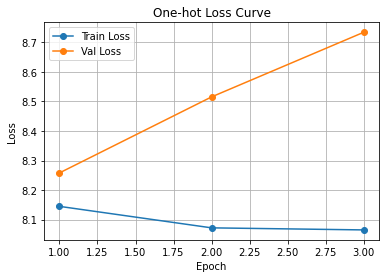

In [29]:
import matplotlib.pyplot as plt

epochs_onehot = range(1, len(train_losses_onehot) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_onehot, train_losses_onehot, marker='o', label='Train Loss')
plt.plot(epochs_onehot, val_losses_onehot, marker='o', label='Val Loss')
plt.title("One-hot Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

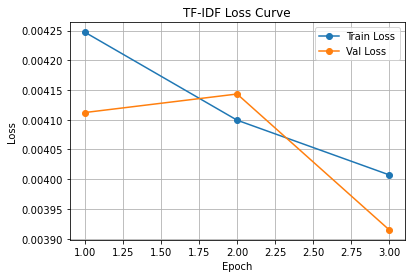

In [30]:
epochs_tfidf = range(1, len(train_losses_tfidf) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_tfidf, train_losses_tfidf, marker='o', label='Train Loss')
plt.plot(epochs_tfidf, val_losses_tfidf, marker='o', label='Val Loss')
plt.title("TF-IDF Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

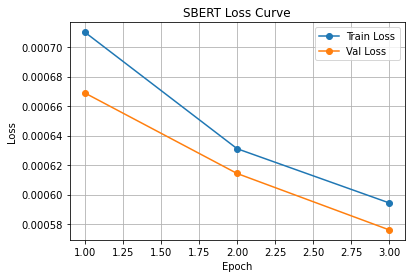

In [31]:
epochs_sbert = range(1, len(train_losses_sbert) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_sbert, train_losses_sbert, marker='o', label='Train Loss')
plt.plot(epochs_sbert, val_losses_sbert, marker='o', label='Val Loss')
plt.title("SBERT Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 17. Axis 1 Results Table

In [32]:
import pandas as pd

axis1_results_table = pd.DataFrame([
    {
        "Representation": "One-hot",
        "Target Dim": target_dims["onehot"],
        "Final Train Loss": train_losses_onehot[-1],
        "Final Val Loss": val_losses_onehot[-1],
        "Final Train Acc": train_accs_onehot[-1],
        "Final Val Acc": val_accs_onehot[-1],
        "Observation": "Trainable, but poor generalisation and very weak classification performance."
    },
    {
        "Representation": "TF-IDF",
        "Target Dim": target_dims["tfidf"],
        "Final Train Loss": train_losses_tfidf[-1],
        "Final Val Loss": val_losses_tfidf[-1],
        "Final Train Acc": None,
        "Final Val Acc": None,
        "Observation": "Stable optimisation; lexical target is easier to learn than full caption classes."
    },
    {
        "Representation": "SBERT",
        "Target Dim": target_dims["sbert"],
        "Final Train Loss": train_losses_sbert[-1],
        "Final Val Loss": val_losses_sbert[-1],
        "Final Train Acc": None,
        "Final Val Acc": None,
        "Observation": "Smoothest and most stable training; semantic target appears easiest to learn."
    }
])

axis1_results_table

,Representation,Target Dim,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc,Observation
0,One-hot,3258,8.065142,8.734374,0.001435,0.0,"Trainable, but poor generalisation and very we..."
1,TF-IDF,178,0.004007,0.003915,NaN,NaN,Stable optimisation; lexical target is easier ...
2,SBERT,384,0.000594,0.000576,NaN,NaN,Smoothest and most stable training; semantic t...


## 18. Test Set Evaluation

In [34]:
@torch.no_grad()
def test_onehot(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        targets_onehot = batch["target"].to(device)

        target_ids = torch.argmax(targets_onehot, dim=1)

        logits = model(images)
        loss = criterion(logits, target_ids)

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == target_ids).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


test_loss_onehot, test_acc_onehot = test_onehot(
    model_onehot, test_loader_onehot, criterion_onehot, device
)

print("One-hot Test Loss:", round(test_loss_onehot, 6))
print("One-hot Test Acc: ", round(test_acc_onehot, 6))

One-hot Test Loss: 8.743931
One-hot Test Acc:  0.0


In [35]:
import torch.nn.functional as F

@torch.no_grad()
def test_vector_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_cosine = 0.0
    total_samples = 0

    for batch in dataloader:
        images = batch["image"].to(device)
        targets = batch["target"].to(device)

        outputs = model(images)
        loss = criterion(outputs, targets)

        total_loss += loss.item() * images.size(0)

        batch_cosine = F.cosine_similarity(outputs, targets, dim=1).mean().item()
        total_cosine += batch_cosine * images.size(0)

        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_cosine = total_cosine / total_samples
    return avg_loss, avg_cosine


test_loss_tfidf, test_cosine_tfidf = test_vector_model(
    model_tfidf, test_loader_tfidf, criterion_tfidf, device
)

print("TF-IDF Test Loss:   ", round(test_loss_tfidf, 6))
print("TF-IDF Test Cosine: ", round(test_cosine_tfidf, 6))

TF-IDF Test Loss:    0.003932
TF-IDF Test Cosine:  0.54671


In [36]:
test_loss_sbert, test_cosine_sbert = test_vector_model(
    model_sbert, test_loader_sbert, criterion_sbert, device
)

print("SBERT Test Loss:   ", round(test_loss_sbert, 6))
print("SBERT Test Cosine: ", round(test_cosine_sbert, 6))

SBERT Test Loss:    0.00057
SBERT Test Cosine:  0.883889


In [37]:
axis1_test_results = pd.DataFrame([
    {
        "Representation": "One-hot",
        "Test Loss": test_loss_onehot,
        "Test Accuracy": test_acc_onehot,
        "Test Cosine": None,
        "Comment": "Full-caption classification baseline"
    },
    {
        "Representation": "TF-IDF",
        "Test Loss": test_loss_tfidf,
        "Test Accuracy": None,
        "Test Cosine": test_cosine_tfidf,
        "Comment": "Lexical vector target"
    },
    {
        "Representation": "SBERT",
        "Test Loss": test_loss_sbert,
        "Test Accuracy": None,
        "Test Cosine": test_cosine_sbert,
        "Comment": "Dense semantic vector target"
    }
])

for col in ["Test Loss", "Test Accuracy", "Test Cosine"]:
    axis1_test_results[col] = axis1_test_results[col].apply(
        lambda x: round(x, 6) if pd.notnull(x) else x
    )

axis1_test_results

,Representation,Test Loss,Test Accuracy,Test Cosine,Comment
0,One-hot,8.743931,0.0,NaN,Full-caption classification baseline
1,TF-IDF,0.003932,NaN,0.546710,Lexical vector target
2,SBERT,0.000570,NaN,0.883889,Dense semantic vector target


## 19. Final Axis 1 Results Table

In [38]:
axis1_final_results = pd.DataFrame([
    {
        "Representation": "One-hot",
        "Target Dim": target_dims["onehot"],
        "Final Train Loss": train_losses_onehot[-1],
        "Final Val Loss": val_losses_onehot[-1],
        "Final Train Acc": train_accs_onehot[-1],
        "Final Val Acc": val_accs_onehot[-1],
        "Test Loss": test_loss_onehot,
        "Test Accuracy": test_acc_onehot,
        "Test Cosine": None,
        "Interpretation": "Very weak baseline; treating each full caption as a class makes the output space too sparse and hard to generalise."
    },
    {
        "Representation": "TF-IDF",
        "Target Dim": target_dims["tfidf"],
        "Final Train Loss": train_losses_tfidf[-1],
        "Final Val Loss": val_losses_tfidf[-1],
        "Final Train Acc": None,
        "Final Val Acc": None,
        "Test Loss": test_loss_tfidf,
        "Test Accuracy": None,
        "Test Cosine": test_cosine_tfidf,
        "Interpretation": "More stable than one-hot; lexical target space is easier to learn because related captions share words."
    },
    {
        "Representation": "SBERT",
        "Target Dim": target_dims["sbert"],
        "Final Train Loss": train_losses_sbert[-1],
        "Final Val Loss": val_losses_sbert[-1],
        "Final Train Acc": None,
        "Final Val Acc": None,
        "Test Loss": test_loss_sbert,
        "Test Accuracy": None,
        "Test Cosine": test_cosine_sbert,
        "Interpretation": "Best overall result; dense semantic targets appear easiest for the image model to learn."
    }
])

for col in [
    "Final Train Loss", "Final Val Loss",
    "Final Train Acc", "Final Val Acc",
    "Test Loss", "Test Accuracy", "Test Cosine"
]:
    axis1_final_results[col] = axis1_final_results[col].apply(
        lambda x: round(x, 6) if pd.notnull(x) else x
    )

axis1_final_results

,Representation,Target Dim,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc,Test Loss,Test Accuracy,Test Cosine,Interpretation
0,One-hot,3258,8.065142,8.734374,0.001435,0.0,8.743931,0.0,NaN,Very weak baseline; treating each full caption...
1,TF-IDF,178,0.004007,0.003915,NaN,NaN,0.003932,NaN,0.546710,More stable than one-hot; lexical target space...
2,SBERT,384,0.000594,0.000576,NaN,NaN,0.000570,NaN,0.883889,Best overall result; dense semantic targets ap...


### Axis 1 result interpretation

The one-hot baseline performed very poorly. This is expected because it treats each full caption as an independent class, creating a large and sparse output space. As a result, the model struggles to generalise beyond exact caption forms.

TF-IDF performed much more stably than one-hot. This suggests that predicting a lexical vector space is easier than full-caption classification, because captions with similar content share important words and phrases.

SBERT gave the strongest overall results. It achieved the smoothest training dynamics and the highest test cosine similarity, suggesting that dense semantic targets are the most learnable representation under the current setup. This supports the hypothesis that semantically structured embeddings generalise better than sparse sentence-level labels.